In [61]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Data Loading

Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```

In [62]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 200
Kelas: ['Grape_black_rot_100', 'daun_sehat_100']


## Data Preparation

### Define Preprocessing Function


In [63]:
TARGET_SIZE = (256, 256)

def gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)

def clahe(image_input, clip_limit=2.0, tile_grid_size=(8, 8)):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    clahe_obj = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    clahe_hasil = clahe_obj.apply(img)

    return clahe_hasil


def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_hasil = cv.medianBlur(img, kernel_size)
    return median_hasil

### Preprocessing

In [64]:
def prepro(image):
    img = gray(image)
    img = median(img)
    img = clahe(img)

    return img

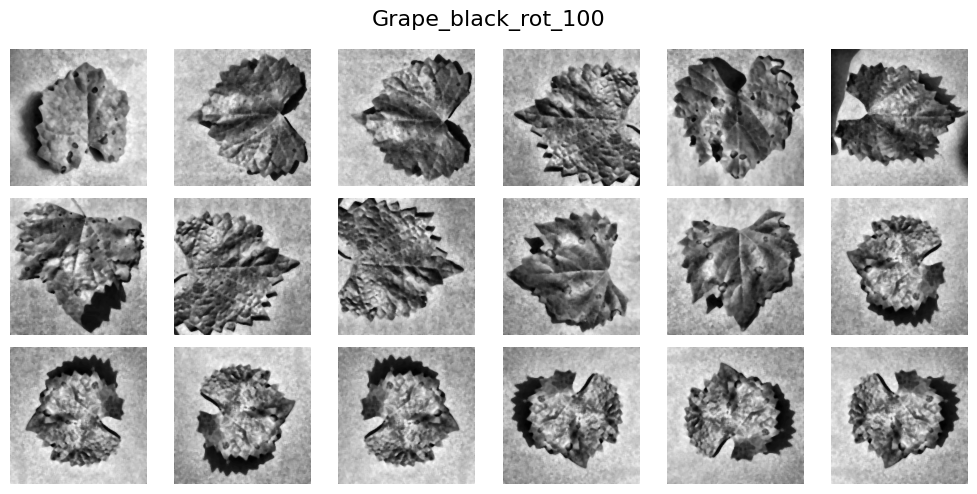

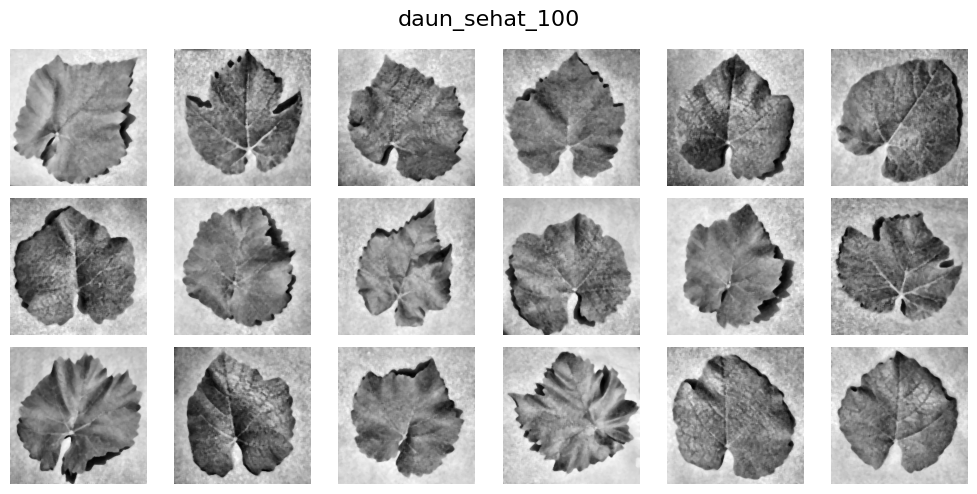

In [65]:
def percobaan3(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan3(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(3, 6, figsize=(10, 5))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(18, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

### Feature Extraction

In [66]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [67]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [68]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [69]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


In [70]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [71]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [72]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [73]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [74]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [75]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [76]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Write the extraction's results to CSV 

In [77]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('./ekstraksi/hasil_ekstraksi3.csv', index=False)

hasilEkstrak = pd.read_csv('./ekstraksi/hasil_ekstraksi3.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,daun_sehat_100_1.jpg,daun_sehat_100,61.603615,110.383468,52.080944,83.457424,0.386290,0.293089,0.412746,0.310737,...,0.001403,0.000860,0.035341,0.028592,0.037455,0.029322,0.979095,0.962520,0.982325,0.971663
1,daun_sehat_100_2.jpg,daun_sehat_100,127.766054,212.363214,115.025536,195.130165,0.284939,0.205561,0.300698,0.204504,...,0.000524,0.000299,0.022372,0.017421,0.022893,0.017281,0.968492,0.947684,0.971635,0.951930
2,daun_sehat_100_3.jpg,daun_sehat_100,84.513266,146.609258,82.684452,132.604752,0.317718,0.210462,0.302460,0.217773,...,0.000547,0.000342,0.024842,0.018250,0.023391,0.018502,0.974788,0.956239,0.975292,0.960419
3,daun_sehat_100_4.jpg,daun_sehat_100,55.810723,94.369550,58.708578,98.974810,0.318033,0.228192,0.332177,0.223297,...,0.000666,0.000381,0.024501,0.019674,0.025801,0.019516,0.980203,0.966511,0.979149,0.964877
4,daun_sehat_100_5.jpg,daun_sehat_100,122.297013,185.583822,95.157368,179.336978,0.256449,0.177429,0.288657,0.190202,...,0.000399,0.000226,0.018590,0.014762,0.019976,0.015046,0.968837,0.952674,0.975705,0.954268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Grape_black_rot_100_96.jpg,Grape_black_rot_100,72.753416,150.653241,95.654963,138.746128,0.282822,0.185730,0.258556,0.188919,...,0.000495,0.000333,0.023746,0.018063,0.022247,0.018255,0.981177,0.961056,0.975251,0.964134
196,Grape_black_rot_100_97.jpg,Grape_black_rot_100,116.660539,212.502345,132.139185,212.040892,0.270816,0.176480,0.267365,0.193264,...,0.000332,0.000212,0.018208,0.013879,0.018218,0.014565,0.982033,0.967268,0.979629,0.967339
197,Grape_black_rot_100_98.jpg,Grape_black_rot_100,68.787714,123.999385,85.137776,137.475356,0.296721,0.201710,0.283035,0.198169,...,0.000428,0.000272,0.022175,0.016559,0.020700,0.016490,0.983939,0.971095,0.980145,0.967953
198,Grape_black_rot_100_99.jpg,Grape_black_rot_100,116.520221,211.799200,131.781970,211.579592,0.271526,0.177941,0.267129,0.192962,...,0.000328,0.000211,0.018173,0.013894,0.018122,0.014513,0.981959,0.967203,0.979575,0.967237


### Features Selection

pada bagian seleksi fitur ini bisa menggunakan metode seperti
- PCA
- LDA
- t-SNE
- Chi-square
- ANOVA
- Autoencoder
- correlation
- dll

berikut contoh menggunakan correlation:

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 9
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Homogeneity0', 'Dissimilarity0', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


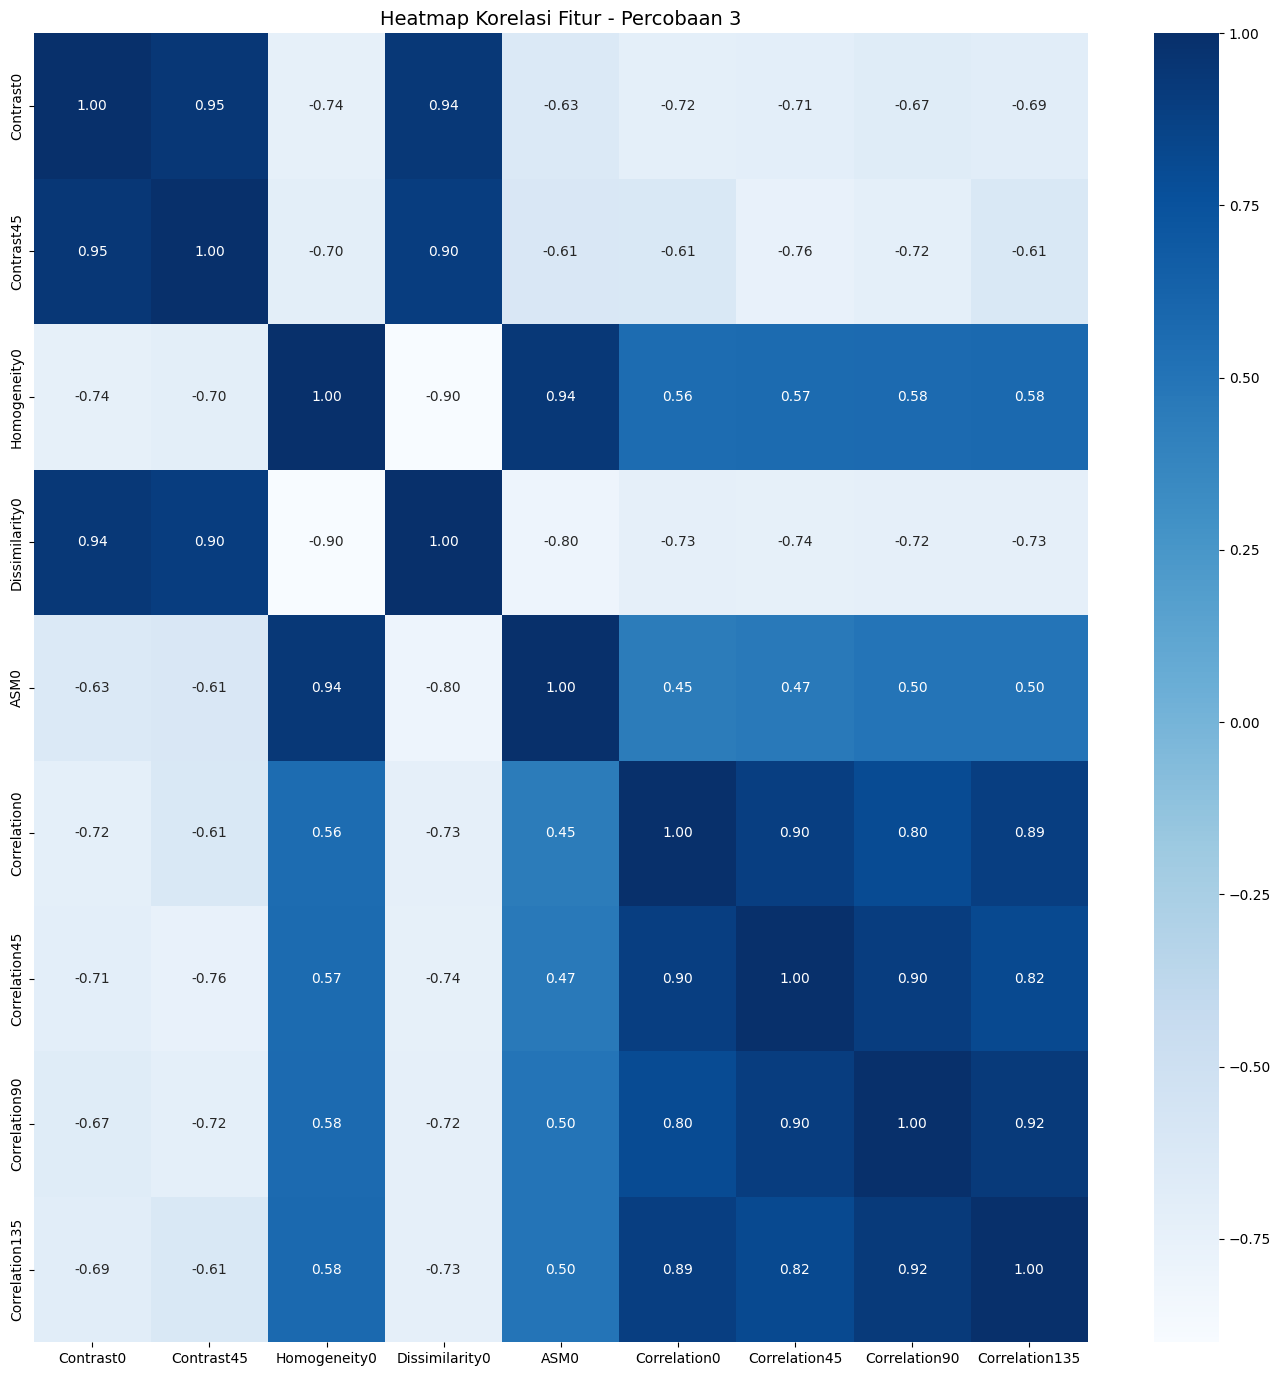

In [78]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

## Splitting Data

In [79]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(160, 9)
(40, 9)


## Feature Normalization

berikut metode normalisasi yang bisa digunakan:
- Min-Max Scaling
- Standardization (Z-score)
- Robust Scaling
- MaxAbsScaler
- dll

berikut contoh menggunakan Standardization (Z-score):

In [80]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Modeling

### Define Model

In [81]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [82]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.94      1.00      0.97        81
     daun_sehat_100       1.00      0.94      0.97        79

           accuracy                           0.97       160
          macro avg       0.97      0.97      0.97       160
       weighted avg       0.97      0.97      0.97       160

[[81  0]
 [ 5 74]]
Accuracy: 0.96875

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.95      0.92        19
     daun_sehat_100       0.95      0.90      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.93      0.92        40
       weighted avg       0.93      0.93      0.93        40

[[18  1]
 [ 2 19]]
Accuracy: 0.925


### Train SVM Classifier

In [83]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.92      0.96      0.94        81
     daun_sehat_100       0.96      0.91      0.94        79

           accuracy                           0.94       160
          macro avg       0.94      0.94      0.94       160
       weighted avg       0.94      0.94      0.94       160

[[78  3]
 [ 7 72]]
Accuracy: 0.9375

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.95      0.95      0.95        19
     daun_sehat_100       0.95      0.95      0.95        21

           accuracy                           0.95        40
          macro avg       0.95      0.95      0.95        40
       weighted avg       0.95      0.95      0.95        40

[[18  1]
 [ 1 20]]
Accuracy: 0.95


### Train KNN Classifier

In [84]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.96      0.93      0.94        81
     daun_sehat_100       0.93      0.96      0.94        79

           accuracy                           0.94       160
          macro avg       0.94      0.94      0.94       160
       weighted avg       0.94      0.94      0.94       160

[[75  6]
 [ 3 76]]
Accuracy: 0.94375

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.95      0.92        19
     daun_sehat_100       0.95      0.90      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.93      0.92        40
       weighted avg       0.93      0.93      0.93        40

[[18  1]
 [ 2 19]]
Accuracy: 0.925


## Evaluation With Confusion Matrix

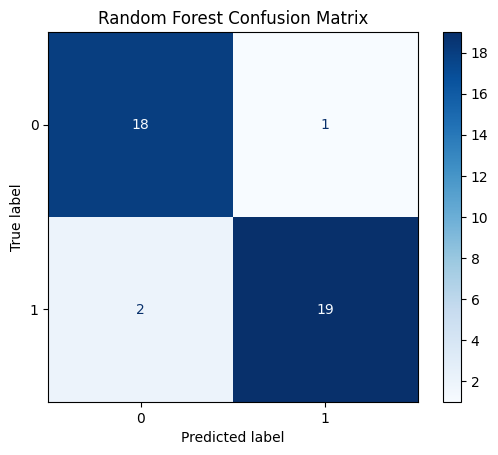

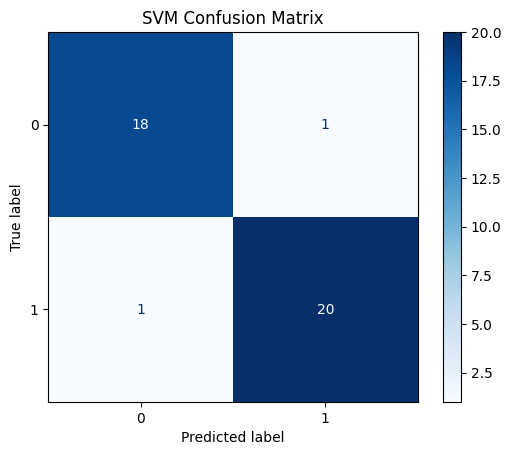

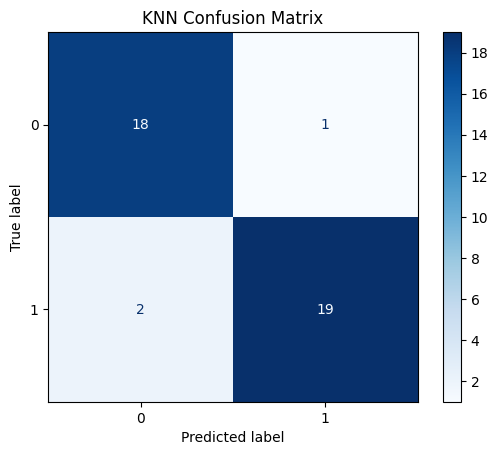

In [85]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

In [86]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./klasifikasi/hasil_klasifikasi3.csv', index=False)
df_hasil

,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.96875,0.925,0.92625,0.925,0.925047
1,SVM,0.93750,0.950,0.95000,0.950,0.950000
2,KNN,0.94375,0.925,0.92625,0.925,0.925047
